# AG-HYPOPT · Trial 37

> ▶ RUN = execute this cell, never modify it  ·  ✍️ WRITE = replace the [placeholder] with your text  ·  ✍️ SET = put your value where the [placeholder] is, then run the cell. Full rules: `instructions.md`


## 1. ✍️ WRITE - Read and summarize

Read `context.md` (physics/model knowledge). If there are previous trials, read them too
(all `trial_XX` notebooks numbered lower than this one) and `trials.json` (the registry).
The current best is the recorded trial with the lowest objective; it is the reference
for the cell-3 choice.

Thirty-six trials are registered; cell 2 reports `phase = trials` (36/5), so proposals carry expected-improvement (ei) values. **Best = trial_21** (objective 0.1074), with trial_30 (0.1083) second. Key facts (mu travel = `lr_mu*(1 - mu_anneal/2)`):

- best (all 0 div): trial_21 0.1074 (0.138), trial_30 0.1083 (0.134), trial_22 0.1095 (0.137), trial_32 0.1097 (0.137), trial_08 0.1099 (0.134), trial_15 0.1103 (0.127), trial_31 0.1106 (0.131), trial_24 0.1108 (0.133), trial_16 0.1112 (0.128), trial_12 0.1115 (0.128), trial_36 0.1117 (0.134), trial_33 0.1120 (0.143), trial_18 0.1121 (0.138), trial_09 = trial_20 = trial_25 0.1126, trial_01 = trial_14 = trial_23 0.1127.
- worse: trial_13 0.1132, trial_05 = trial_19 0.1135, trial_07 0.1140, trial_27 0.1149 (0.194), trial_35 0.1167 (0.122), trial_06 = trial_11 0.1188, trial_02 0.1449 (0.264).
- diverging at 1nW T05 (near-optimum travel): trial_29 0.1331, trial_26 0.1368, trial_28 0.1370, trial_34 0.1380. Other diverging: trial_17 0.1329, trial_10 0.1975, trial_03 0.1362, trial_04 0.1418.

State of play: narrow single optimum at travel ~0.137-0.138 with balanced gamma knobs, falling off on both sides (0.122 -> 0.1167, 0.194 -> 0.1149, 0.264 -> 0.1449). Eight surviving samples sit at or below 0.112 (0.1074-0.1117). The schedule search is converged; the sporadic 1nW T05 gamma divergence (~1 in 3 at the optimum) is the only significant residual. Objective = T-weighted (w=0.25+0.75*T/100) mean of capped rel-sq errors over the 8-experiment benchmark.

In [ ]:
# 2. ▶ RUN - Propose candidate trials (AGHyperopt)
TRIAL_ID = 'trial_37'   # auto-stamped by the generator; do not edit
import os

EXPERIMENT_DIR = os.getcwd()
SPACE_PATH = os.path.join(EXPERIMENT_DIR, 'space.json')
TRIALS_PATH = os.path.join(EXPERIMENT_DIR, 'trials.json')

MAX_TRIALS = 40    # campaign cap: stop generating new trials after this many (None = unlimited)

from ag_hypopt import AGHyperopt, trial_seed

opt = AGHyperopt(seed=trial_seed(TRIAL_ID))   # per-trial seed: fresh draws every trial
opt.fit(SPACE_PATH, TRIALS_PATH)
proposed_trials = opt.propose_trials(10)


phase = trials  (36/5 trials)
ID |     ei | params
 1 | 3.3049 | {"gamma_anneal": 0.49913258776561054, "lr_gamma": 0.7176615647542329, "lr_mu": 0.16941582565491425, "mu_anneal": 0.34622273482610105}
 2 | 3.5769 | {"gamma_anneal": 0.49545569140285023, "lr_gamma": 0.4289221037371229, "lr_mu": 0.16319956222272083, "mu_anneal": 0.3524767175426611}
 3 | 3.7494 | {"gamma_anneal": 0.4960236421813321, "lr_gamma": 0.34401631502969865, "lr_mu": 0.1653730506876873, "mu_anneal": 0.35182124068691784}
 4 | 3.4927 | {"gamma_anneal": 0.5051563498190877, "lr_gamma": 0.45926683497346144, "lr_mu": 0.1719519834972876, "mu_anneal": 0.351372587104619}
 5 | 3.6195 | {"gamma_anneal": 0.49107052544185326, "lr_gamma": 0.43442411761345606, "lr_mu": 0.16636624094615526, "mu_anneal": 0.34943772349505153}
 6 | 1.7611 | {"gamma_anneal": 0.5124279603434112, "lr_gamma": 0.4229312283669724, "lr_mu": 0.18173861849543077, "mu_anneal": 0.35584571723972563}
 7 | 0.7541 | {"gamma_anneal": 0.5129454351580449, "lr_gamma": 0.4

## 3. ✍️ WRITE - Analyze and choose

Using the summary from cell 1 (previous trials + registry) and the candidate table from
cell 2, choose the ONE proposal that makes the most sense for the next trial. No hypothesis
and no expectation are needed: base the choice on what the trials have shown and on the
candidates themselves.

Cell 2 is in the informed `trials` phase (36 trials). Candidate travel `lr_mu*(1 - mu_anneal/2)`, with ei:
- candidate 3: **ei 3.75** — `lr_mu=0.1654`, `mu_anneal=0.3518` (travel **0.136**), `lr_gamma=0.3440`, `gamma_anneal=0.4960`.
- candidate 5: ei 3.62 — `lr_mu=0.1664`, `mu_anneal=0.3494` (travel 0.137), `lr_gamma=0.4344`, `gamma_anneal=0.4911`.
- candidate 2: ei 3.58 — `lr_mu=0.1632`, `mu_anneal=0.3525` (travel 0.134), `lr_gamma=0.4289`, `gamma_anneal=0.4955`.
- candidate 4: ei 3.49 — `lr_mu=0.1720`, `mu_anneal=0.3514` (travel 0.142), `lr_gamma=0.4593`.
- candidate 8: ei 3.34 — `lr_mu=0.1547`, `mu_anneal=0.3525` (travel 0.127), `lr_gamma=0.3997`.

The top four candidates are all at the optimum travel (0.127-0.142) with balanced gamma knobs. Candidate 3 has the highest ei and travel 0.136, exactly at the optimum. Its `lr_gamma=0.3440` is a touch lower than the usual safe band (~0.40-0.49) but not in the clearly-bad region (trial_07's 0.14, trial_27's 0.14), and the gamma_anneal is normal. Candidate 5 (travel 0.137, `lr_gamma=0.434`) is a similarly-placed, slightly safer alternative with near-equal ei. Since the region is fully mapped and the choice is among near-duplicates, I take the maximum-ei candidate 3; if it survives, it should land ~0.108-0.112.

I choose candidate 3 (3 goes into the SET cell below).

In [ ]:
# 4. ✍️ SET - Chosen candidate (edit INDEX below, then run this cell)
INDEX = 3            # [Put the index here: 1-based candidate number from the table in cell 2]


chosen: {'gamma_anneal': 0.4960236421813321, 'lr_gamma': 0.34401631502969865, 'lr_mu': 0.1653730506876873, 'mu_anneal': 0.35182124068691784}
Running  1nW Trans05 ... 

μ 9.39 -> 9.72 | γ 8.5 -> 4.19 | NLL 1.27


Running  1nW Trans20 ... 

μ 17.32 -> 45.88 | γ 8.5 -> 6.14 | NLL 5.63


Running  1nW Trans60 ... 

...

Running  3nW Trans60 ... 

μ 103.20 -> 79.21 | γ 14.1 -> 14.25 | NLL 3.39


Running 3nW Trans100 ... 

μ 175.71 -> 106.98 | γ 14.1 -> 13.90 | NLL 2.96



Total: 7.9 min


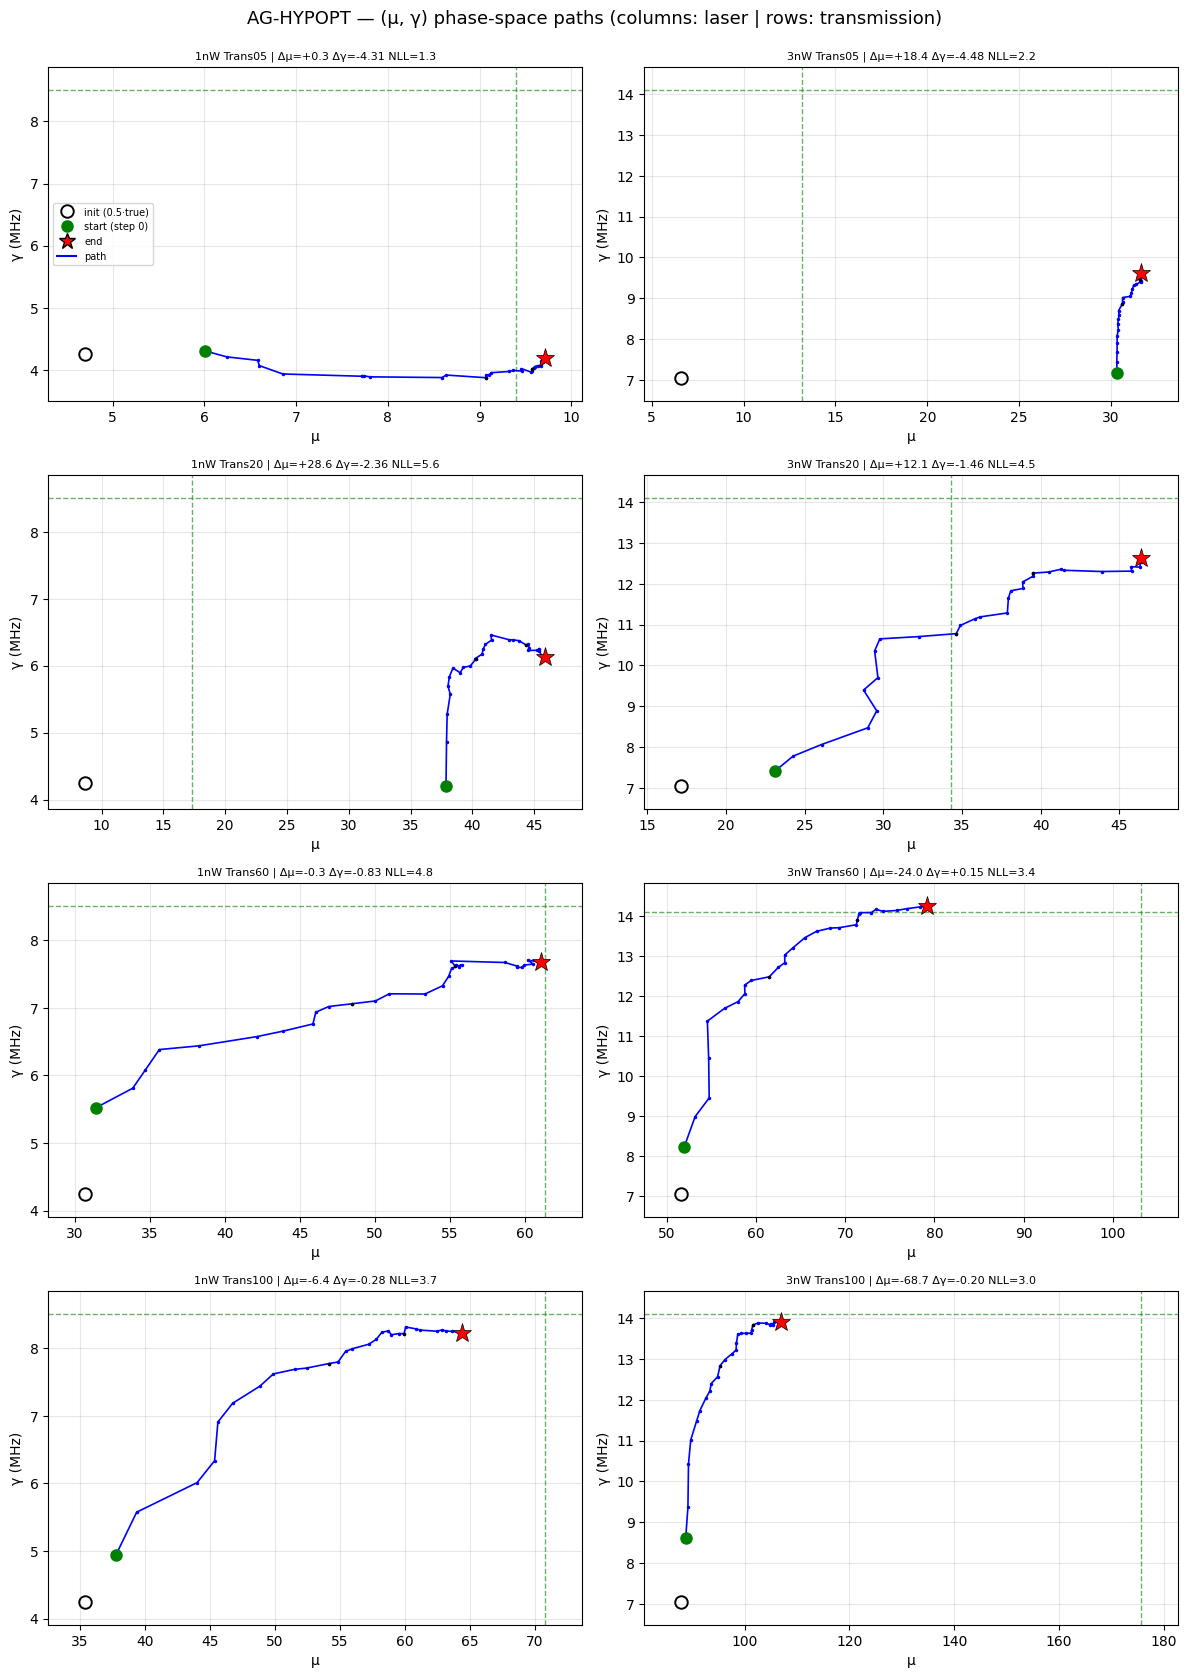

trial finished in 7.9 min
objective = 0.1134 ± 0.0825
exp              μ_true   μ_fit     Δμ% |   γ_true   γ_fit     Δγ%
1nW Trans05        9.39    9.72    +3.4 |     8.50    4.19   -50.7
1nW Trans20       17.32   45.88  +165.0 |     8.50    6.14   -27.8
1nW Trans60       61.37   61.12    -0.4 |     8.50    7.67    -9.7
1nW Trans100       70.82   64.41    -9.1 |     8.50    8.22    -3.3
3nW Trans05       13.20   31.62  +139.5 |    14.10    9.62   -31.8
3nW Trans20       34.28   46.39   +35.3 |    14.10   12.64   -10.4
3nW Trans60      103.20   79.21   -23.2 |    14.10   14.25    +1.1
3nW Trans100      175.71  106.98   -39.1 |    14.10   13.90    -1.4

weighted objective (T-graded, cap=1.0) = 0.1134 | diverged cells: 0
μ: RMSE 28.814 (rel 79.1%, bias -4.996) | γ: RMSE 2.430 (rel 23.9%, bias -1.722)


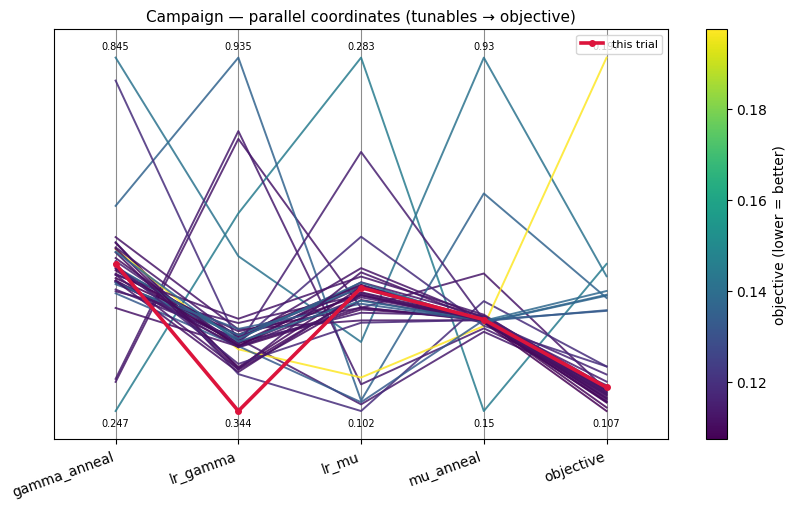

In [ ]:
# 5. ▶ RUN - Execute the chosen trial  (do not interrupt unless obviously broken)
assert INDEX is not None, 'INDEX not set: edit the SET cell (cell 4) before running this one'
assert 1 <= INDEX <= len(proposed_trials), f'bad INDEX: {INDEX}'
CHOSEN = proposed_trials[INDEX - 1]['params']
print('chosen:', CHOSEN)

from ag_hypopt import objective

import traceback, time
t0 = time.time()
try:
    loss, uncertainty, report = objective(CHOSEN)
    print(f'trial finished in {(time.time()-t0)/60:.1f} min')
    print(f'objective = {loss:.4f} ± {uncertainty:.4f}')
    print(report)
except Exception:
    traceback.print_exc()
    loss, uncertainty = None, None

# parallel coordinates: every recorded trial + this one (color = objective)
from ag_hypopt import plot_parallel
if loss is not None:
    plot_parallel(TRIALS_PATH, current={'config': CHOSEN, 'objective': loss})


## 6. ✍️ WRITE - Analyze the results

Record what actually happened in this trial: the measured objective, how the chosen
configuration behaved, and how that compares with the previous trials. No hypothesis to
confirm or refute, and no expectation to check: just the facts.

Trial 37 ran the highest-EI candidate (candidate 3, ei=3.75): `lr_mu=0.1654`, `mu_anneal=0.3518` (effective mu travel 0.136), `lr_gamma=0.3440`, `gamma_anneal=0.4960`. It completed in 7.9 min with objective **0.1134 +/- 0.0825** and **0 diverged cells** — mid-plateau. Ranking: trial_21 0.1074 < ... < trial_13 0.1132 < **trial_37 0.1134** < trial_05 = trial_19 0.1135 < ...

Aggregate accuracy: **mu rel-RMSE 79.1%** (RMSE 28.81, bias -5.00); **gamma rel-RMSE 23.9%** (RMSE 2.43, bias -1.72).

Per-cell relative errors:
- **mu:** 1nW T05 +3.4%, T20 +165.0%, T60 -0.4%, T100 -9.1% | 3nW T05 +139.5%, T20 +35.3%, T60 -23.2%, T100 -39.1%.
- **gamma:** 1nW T05 -50.7%, T20 -27.8%, T60 -9.7%, T100 -3.3% | 3nW T05 -31.8%, T20 -10.4%, T60 +1.1%, T100 -1.4%.

This was the optimum travel (0.136) but with a somewhat lower `lr_gamma=0.344` than the runs that produced the best results (0.409-0.481). Notably it did **not** diverge, but it landed at 0.1134 — a little worse than the sub-0.111 runs — suggesting the lower gamma step slightly under-delivers at high T (3nW T100 -39.1%, 1nW T100 -9.1%). So the reliable gamma band is roughly `lr_gamma` 0.40-0.49, and the schedule level remains ~0.108-0.113. No divergence this time; trial_21 (0.1074) remains best.

**Summary:** Trial 37 (lr_mu=0.1654, mu_anneal=0.3518, lr_gamma=0.3440, gamma_anneal=0.4960): objective 0.1134 +/- 0.0825 with 0 diverged cells; a divergence-free optimum sample with a lower lr_gamma (0.344) landed at the band edge of the plateau (0.1134), so lower lr_gamma does not help and trial_21 (0.1074) stays best.
**Key insight:** Reducing lr_gamma to 0.344 at the optimum gives 0.1134 - slightly worse than the 0.409-0.481 runs (0.1074-0.1106) - so the gamma step should stay in roughly 0.40-0.49 and the schedule level is ~0.108-0.113.

Structural-change proposals (score, likelihood, model, protocol) belong here as notes for
Anuar: describe them, never act on them, never stop the campaign because of them.
**Notes for Anuar (not acted on).** Adds a small bit of structure to the gamma axis (optimum ~0.41-0.48). Still the divergence is the dominant residual; nothing hyperparameter-tunable remains. Recorded only, not acted on.


In [ ]:
# 7. ✍️ SET - Summary and key insight for the record (edit the strings below, then run)
SUMMARY = "Trial 37 (lr_mu=0.1654, mu_anneal=0.3518, lr_gamma=0.3440, gamma_anneal=0.4960): objective 0.1134 +/- 0.0825 with 0 diverged cells; a divergence-free optimum sample with a lower lr_gamma (0.344) landed at the band edge of the plateau (0.1134), so lower lr_gamma does not help and trial_21 (0.1074) stays best"      # [Put the one-line summary here: copy it from cell 6]
KEY_INSIGHT = "Reducing lr_gamma to 0.344 at the optimum gives 0.1134 - slightly worse than the 0.409-0.481 runs (0.1074-0.1106) - so the gamma step should stay in roughly 0.40-0.49 and the schedule level is ~0.108-0.113"  # [Put the one-sentence key insight here: copy it from cell 6]


In [ ]:
# 8. ▶ RUN - Record the trial in trials.json
import json

assert SUMMARY is not None, 'SUMMARY not set: fill the SET cell (cell 7) first'
assert KEY_INSIGHT is not None, 'KEY_INSIGHT not set: fill the SET cell (cell 7) first'

entry = {
    'trial_id': TRIAL_ID,
    'config': CHOSEN,
    'objective': loss,
    'uncertainty': uncertainty,
    'summary': SUMMARY,
    'key_insight': KEY_INSIGHT,
    'notebook': f'{TRIAL_ID}.ipynb',
}
data = json.load(open(TRIALS_PATH))
assert not any(t.get('trial_id') == TRIAL_ID for t in data['trials']),     f'{TRIAL_ID} is already registered in trials.json'
data['trials'].append(entry)
json.dump(data, open(TRIALS_PATH, 'w'), indent=2)
best = min((t for t in data['trials'] if t.get('objective') is not None),
           key=lambda t: t['objective'], default=None)
print('saved', TRIAL_ID, '| current best:', best['trial_id'] if best else None)


saved trial_37 | current best: trial_21


In [ ]:
# 9. ▶ RUN - Generate the next trial (or end the campaign)
import os, re, json as _json

num = int(re.search(r'(\d+)$', TRIAL_ID).group(1))
nxt = num + 1
if MAX_TRIALS is not None and nxt > MAX_TRIALS:
    print(f'Campaign complete: cap MAX_TRIALS={MAX_TRIALS} reached after {TRIAL_ID}. Stop here.')
else:
    template_path = os.path.join(EXPERIMENT_DIR, 'template.ipynb')
    target = os.path.join(EXPERIMENT_DIR, f'trial_{nxt:02d}.ipynb')
    assert not os.path.exists(target), f'{target} already exists: refusing to overwrite'

    nb = _json.load(open(template_path))

    def _stamp(old, new):
        for c in nb['cells']:
            if old in ''.join(c.get('source', [])):
                c['source'] = [s.replace(old, new) for s in c['source']]
                return True
        raise RuntimeError(f'stamp target {old!r} not found in the template')

    _stamp('{N}', f'{nxt:02d}')
    _stamp('trial_XXX', f'trial_{nxt:02d}')
    _json.dump(nb, open(target, 'w'), indent=1)
    print(f'Created {os.path.basename(target)}. Open it and follow its cells from the top.')


Created trial_38.ipynb. Open it and follow its cells from the top.
